# Data audit

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

DATA_PATH = '../steam_reviews 1.csv'
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

**Check for missing values and duplicates**

In [9]:
print('=== DTYPES ===')
print(df.dtypes)
print()
print('=== MISSING VALUES ===')
print(df.isna().sum())
print()
print('=== DUPLICATE ROWS ===', df.duplicated().sum())
print()
print('=== NUMERIC RANGES ===')
print(df[['funny', 'helpful', 'hour_played']].describe().T[['min', '50%', 'mean', 'max']])

=== DTYPES ===
date_posted                 str
funny                     int64
helpful                   int64
hour_played               int64
is_early_access_review     bool
recommendation              str
review                      str
title                       str
dtype: object

=== MISSING VALUES ===
date_posted               0
funny                     0
helpful                   0
hour_played               0
is_early_access_review    0
recommendation            0
review                    7
title                     0
dtype: int64

=== DUPLICATE ROWS === 0

=== NUMERIC RANGES ===
             min    50%        mean     max
funny        0.0    0.0    1.113019  5274.0
helpful      0.0    0.0    3.715537  2464.0
hour_played  0.0  122.0  296.143395  9567.0


**FINDING - review has 7 missing values**

## Target balance

In [11]:
print(df['recommendation'].value_counts())
print()
print(df['recommendation'].value_counts(normalize=True).round(3))

recommendation
Recommended        10394
Not Recommended     4223
Name: count, dtype: int64

recommendation
Recommended        0.711
Not Recommended    0.289
Name: proportion, dtype: float64


**Takeaway:** 71% Recommended / 29% Not Recommended — moderately imbalanced.

# Cleaning - AI used here

In [12]:
df_clean = df.copy()
n0 = len(df_clean)

df_clean['date_posted'] = pd.to_datetime(df_clean['date_posted'], errors='coerce')
print('Unparseable dates:', df_clean['date_posted'].isna().sum())
print('Date range:', df_clean['date_posted'].min().date(), '->', df_clean['date_posted'].max().date())

null_text = df_clean['review'].isna()
print(f'Dropping {null_text.sum()} reviews with no text (cannot score sentiment without text)')
df_clean = df_clean[~null_text].copy()

fixes = {t: t.replace('™', '').replace('®', '').strip()
         for t in df_clean['title'].unique() if not t.isascii()}
print('Title normalisation:', fixes)
df_clean['title'] = df_clean['title'].replace(fixes)

zero_hr = (df_clean['hour_played'] == 0).sum()
print(f'{zero_hr} reviews report 0 hours played - kept (likely <0.5h rounded down); they feed the engagement insight below')

counts = df_clean['title'].value_counts()
df_clean['thin_coverage'] = df_clean['title'].map(counts) < 100
n_thin = df_clean.loc[df_clean['thin_coverage'], 'title'].nunique()
print(f'thin_coverage flag set for {n_thin} titles with under 100 reviews')

print(f'Rows: {n0:,} -> {len(df_clean):,}')

Unparseable dates: 0
Date range: 2010-12-20 -> 2019-02-16
Dropping 7 reviews with no text (cannot score sentiment without text)
Title normalisation: {'Rocket League®': 'Rocket League', 'ACE COMBAT™ 7: SKIES UNKNOWN': 'ACE COMBAT 7: SKIES UNKNOWN'}
337 reviews report 0 hours played - kept (likely <0.5h rounded down); they feed the engagement insight below
thin_coverage flag set for 5 titles with under 100 reviews
Rows: 14,617 -> 14,610


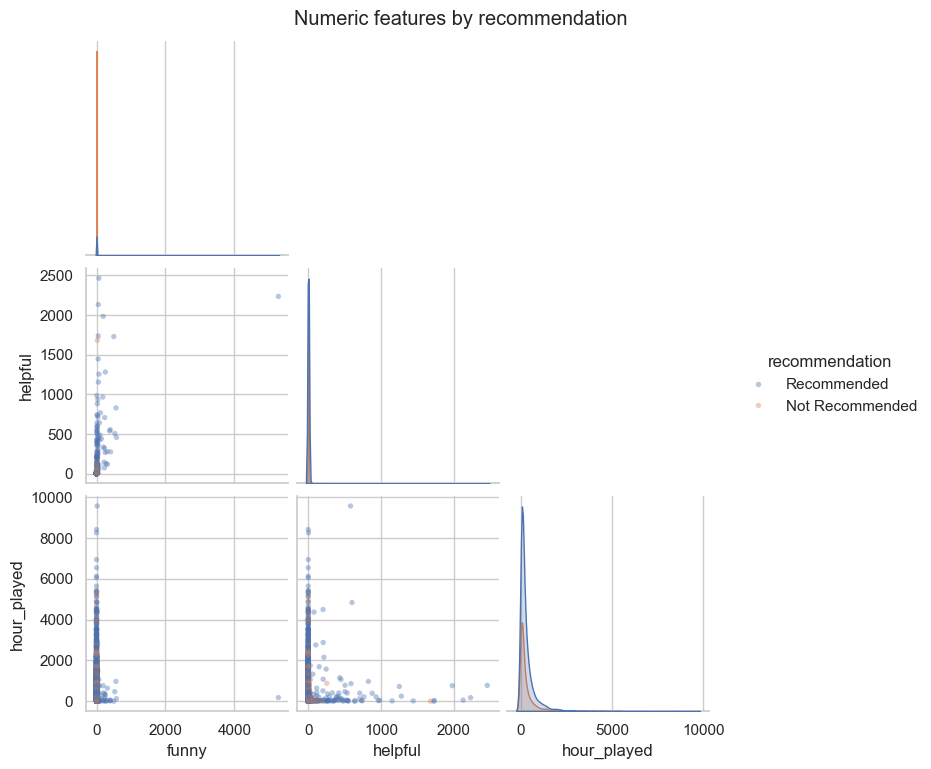

In [10]:
# Pairwise relationships of the numeric features, coloured by the target
features = ['funny', 'helpful', 'hour_played']
g = sns.pairplot(
    df[features + ['recommendation']],
    hue='recommendation',
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15, 'edgecolor': 'none'},
    corner=True,
)
g.fig.suptitle('Numeric features by recommendation', y=1.02)
plt.show()